In [70]:
import kagglehub

path = kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test")


In [71]:
import pandas as pd
import os


tsv_file = os.path.join(path, 'WA_Marketing-Campaign.csv')

df = pd.read_csv(tsv_file)


In [72]:
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


In [74]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


In [75]:
df["Promotion"].unique()

array([3, 2, 1])

In [79]:
df.groupby("Promotion")["SalesInThousands"].mean()

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

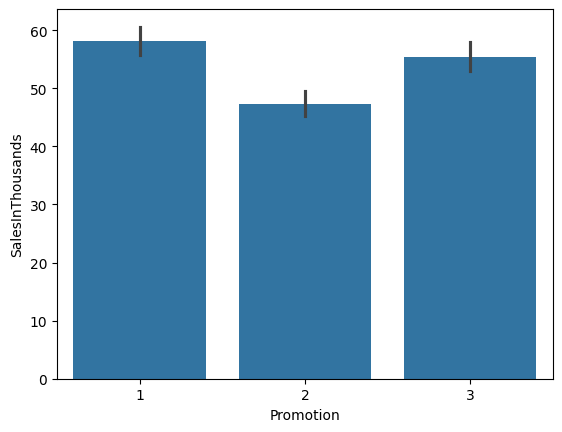

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Promotion", y="SalesInThousands", data=df)
plt.show()

In [77]:
#f_stat → shows how strong the difference is
#p_value → tells if the difference is real or just luck
#f_oneway → the test that compares 3 group

from scipy import stats

promo1 = df[df["Promotion"] == 1]["SalesInThousands"]
promo2 = df[df["Promotion"] == 2]["SalesInThousands"]
promo3 = df[df["Promotion"] == 3]["SalesInThousands"]

f_stat, p_value = stats.f_oneway(promo1, promo2, promo3)

print("F-stat:", f_stat)
print(f"P-value: {p_value:.12f}")

F-stat: 21.953485793080677
P-value: 0.000000000677
